# 03 — Round-of-32 Scenario Explorer

An interactive-by-function analysis of the 16 Round-of-32 forecasts. It compares 90-minute outcomes with advancement probabilities, inspects scoreline distributions, identifies upset candidates, and runs Monte Carlo simulations of the full round.

**Repository:** SambaSportAI World Cup 2026 Forecasting Pipeline  
**Execution:** Run from the repository root or directly from the `notebooks/` folder.  
**Reproducibility:** All inputs are read from version-controlled CSV/JSON artifacts in this repository.

In [1]:
from pathlib import Path
import json
import math
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    # Common fallback when launched from notebooks/ via Jupyter.
    fallback = Path.cwd().resolve().parent
    if (fallback / "pyproject.toml").exists():
        return fallback
    raise FileNotFoundError("Could not locate repository root. Launch Jupyter inside the repository.")

ROOT = find_repo_root()
print(f"Repository root: {ROOT}")

Repository root: /mnt/data/sambasportai-world-cup-2026


## 1. Load Round-of-32 predictions

In [2]:
predictions = pd.read_csv(ROOT / "outputs" / "predictions" / "round_of_32_predictions.csv")

def parse_jsonish(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        return json.loads(value)
    except Exception:
        return ast.literal_eval(value)

predictions["top_scorelines"] = predictions["top_scorelines_90"].apply(parse_jsonish)
predictions["fixture"] = predictions["home_team"] + " vs " + predictions["away_team"]
display(predictions[[
    "date", "fixture", "p_home_win_90", "p_draw_90", "p_away_win_90",
    "p_home_advance", "p_away_advance", "expected_score", "most_likely_score_90",
    "predicted_advancing_team"
]].round(3))

,date,fixture,p_home_win_90,p_draw_90,p_away_win_90,p_home_advance,p_away_advance,expected_score,most_likely_score_90,predicted_advancing_team
0,2026-06-28,South Africa vs Canada,0.195,0.196,0.610,0.264,0.736,1-2,0-1,Canada
1,2026-06-29,Germany vs Paraguay,0.543,0.283,0.174,0.721,0.279,2-1,1-1,Germany
2,2026-06-29,Brazil vs Japan,0.520,0.308,0.172,0.711,0.289,2-1,1-1,Brazil
3,2026-06-29,Netherlands vs Morocco,0.470,0.285,0.245,0.627,0.373,2-1,1-1,Netherlands
4,2026-06-30,Ivory Coast vs Norway,0.328,0.241,0.431,0.413,0.587,1-1,1-1,Norway
5,2026-06-30,France vs Sweden,0.624,0.306,0.069,0.881,0.119,2-1,1-0,France
6,2026-06-30,Mexico vs Ecuador,0.549,0.132,0.320,0.624,0.376,2-1,2-0,Mexico
7,2026-07-01,England vs DR Congo,0.620,0.305,0.076,0.866,0.134,2-1,1-0,England
8,2026-07-01,United States vs Bosnia and Herzegovina,0.655,0.171,0.174,0.781,0.219,2-1,1-0,United States
9,2026-07-01,Belgium vs Senegal,0.512,0.301,0.187,0.679,0.321,2-1,1-0,Belgium


## 2. Select and inspect a fixture

,value
date,2026-06-28
city,Inglewood
home_team,South Africa
away_team,Canada
home_win_90,0.194645
draw_90,0.19557
away_win_90,0.609785
home_advance,0.26384
away_advance,0.73616
expected_score,1-2


,score,probability
0,0-1,0.119072
1,1-1,0.115435
2,0-2,0.099632
3,1-2,0.096589
4,0-0,0.071153


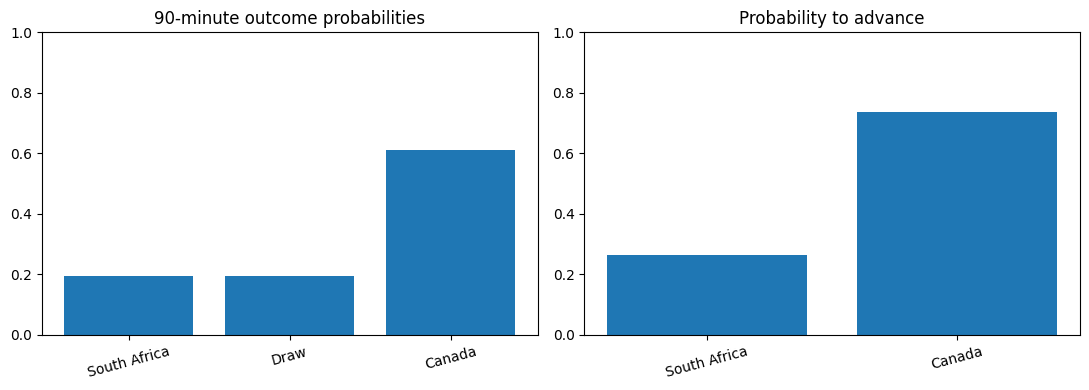

In [3]:
def show_fixture(fixture):
    row = predictions.loc[predictions["fixture"] == fixture].iloc[0]
    summary = pd.Series({
        "date": row["date"],
        "city": row["city"],
        "home_team": row["home_team"],
        "away_team": row["away_team"],
        "home_win_90": row["p_home_win_90"],
        "draw_90": row["p_draw_90"],
        "away_win_90": row["p_away_win_90"],
        "home_advance": row["p_home_advance"],
        "away_advance": row["p_away_advance"],
        "expected_score": row["expected_score"],
        "most_likely_score_90": row["most_likely_score_90"],
        "predicted_advancing_team": row["predicted_advancing_team"],
        "home_tournament_elo": row["home_tournament_elo"],
        "away_tournament_elo": row["away_tournament_elo"],
    }, name="value")
    display(summary.to_frame())

    scorelines = pd.DataFrame(row["top_scorelines"])
    if "probability" not in scorelines and "prob" in scorelines:
        scorelines = scorelines.rename(columns={"prob": "probability"})
    display(scorelines)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar([row["home_team"], "Draw", row["away_team"]], [row["p_home_win_90"], row["p_draw_90"], row["p_away_win_90"]])
    axes[0].set_ylim(0, 1)
    axes[0].set_title("90-minute outcome probabilities")
    axes[0].tick_params(axis="x", rotation=15)

    axes[1].bar([row["home_team"], row["away_team"]], [row["p_home_advance"], row["p_away_advance"]])
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Probability to advance")
    axes[1].tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()
    return row

fixture = predictions["fixture"].iloc[0]  # change this string to inspect another game
selected = show_fixture(fixture)

## 3. Most uncertain games and upset candidates

In [4]:
predictions["advance_margin"] = (predictions["p_home_advance"] - predictions["p_away_advance"]).abs()
predictions["underdog_advance_probability"] = predictions[["p_home_advance", "p_away_advance"]].min(axis=1)
predictions["favorite_advance_probability"] = predictions[["p_home_advance", "p_away_advance"]].max(axis=1)

display(Markdown("### Closest advancement calls"))
display(predictions.sort_values("advance_margin")[[
    "fixture", "p_home_advance", "p_away_advance", "predicted_advancing_team", "expected_score", "most_likely_score_90"
]].head(8).round(3))

display(Markdown("### Highest underdog advancement probabilities"))
display(predictions.sort_values("underdog_advance_probability", ascending=False)[[
    "fixture", "underdog_advance_probability", "favorite_advance_probability", "predicted_advancing_team"
]].head(8).round(3))

### Closest advancement calls

,fixture,p_home_advance,p_away_advance,predicted_advancing_team,expected_score,most_likely_score_90
4,Ivory Coast vs Norway,0.413,0.587,Norway,1-1,1-1
6,Mexico vs Ecuador,0.624,0.376,Mexico,2-1,2-0
3,Netherlands vs Morocco,0.627,0.373,Netherlands,2-1,1-1
10,Portugal vs Croatia,0.639,0.361,Portugal,1-1,1-1
14,Australia vs Egypt,0.647,0.353,Australia,1-1,1-1
9,Belgium vs Senegal,0.679,0.321,Belgium,2-1,1-0
12,Switzerland vs Algeria,0.708,0.292,Switzerland,1-1,1-0
2,Brazil vs Japan,0.711,0.289,Brazil,2-1,1-1


### Highest underdog advancement probabilities

,fixture,underdog_advance_probability,favorite_advance_probability,predicted_advancing_team
4,Ivory Coast vs Norway,0.413,0.587,Norway
6,Mexico vs Ecuador,0.376,0.624,Mexico
3,Netherlands vs Morocco,0.373,0.627,Netherlands
10,Portugal vs Croatia,0.361,0.639,Portugal
14,Australia vs Egypt,0.353,0.647,Australia
9,Belgium vs Senegal,0.321,0.679,Belgium
12,Switzerland vs Algeria,0.292,0.708,Switzerland
2,Brazil vs Japan,0.289,0.711,Brazil


## 4. Monte Carlo simulation of the complete Round of 32

,probability
0,0.0072
1,0.0424
2,0.1184
3,0.1997
4,0.2310
5,0.1946
6,0.1199
7,0.0579
8,0.0212
9,0.0059


Expected number of underdog advances: 4.14 out of 16
Probability of at least 4 underdog advances: 63.2%


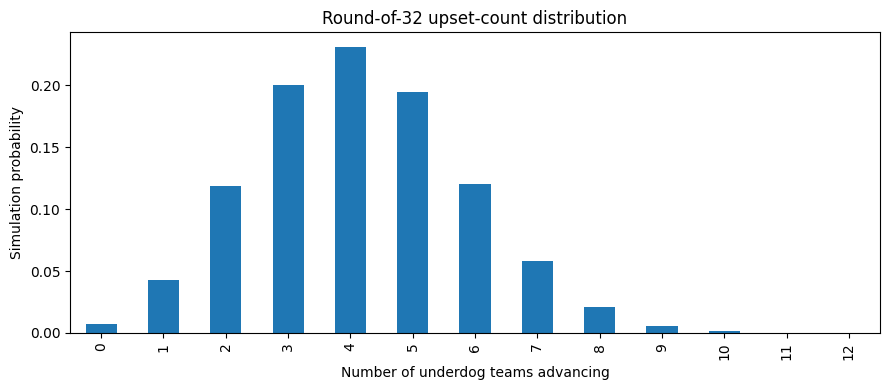

In [5]:
def simulate_round(n_simulations=100_000, seed=2026):
    rng = np.random.default_rng(seed)
    home_probs = predictions["p_home_advance"].to_numpy(float)
    # True means the home team advances.
    home_advances = rng.random((n_simulations, len(predictions))) < home_probs
    upset_prob = predictions[["p_home_advance", "p_away_advance"]].min(axis=1).to_numpy(float)
    favorite_is_home = predictions["p_home_advance"].to_numpy(float) >= predictions["p_away_advance"].to_numpy(float)
    favorite_advances = np.where(favorite_is_home[None, :], home_advances, ~home_advances)
    upset_counts = (~favorite_advances).sum(axis=1)
    return home_advances, upset_counts

home_advances, upset_counts = simulate_round()
upset_distribution = pd.Series(upset_counts).value_counts(normalize=True).sort_index().rename("probability").to_frame()
display(upset_distribution.head(10).round(4))

print(f"Expected number of underdog advances: {upset_counts.mean():.2f} out of 16")
print(f"Probability of at least 4 underdog advances: {(upset_counts >= 4).mean():.1%}")

ax = pd.Series(upset_counts).value_counts(normalize=True).sort_index().plot(kind="bar", figsize=(9, 4))
ax.set_xlabel("Number of underdog teams advancing")
ax.set_ylabel("Simulation probability")
ax.set_title("Round-of-32 upset-count distribution")
plt.tight_layout()
plt.show()

## 5. Team advancement frequency check

In [6]:
rows = []
for j, row in predictions.iterrows():
    home_frequency = home_advances[:, j].mean()
    rows.append({
        "team": row["home_team"],
        "side": "home",
        "input_probability": row["p_home_advance"],
        "simulation_frequency": home_frequency,
    })
    rows.append({
        "team": row["away_team"],
        "side": "away",
        "input_probability": row["p_away_advance"],
        "simulation_frequency": 1 - home_frequency,
    })
simulation_check = pd.DataFrame(rows).sort_values("input_probability", ascending=False)
display(simulation_check.round(4))

,team,side,input_probability,simulation_frequency
26,Argentina,home,0.9135,0.9143
22,Spain,home,0.8877,0.8865
10,France,home,0.8809,0.8786
14,England,home,0.8657,0.8664
30,Colombia,home,0.8516,0.8542
16,United States,home,0.7807,0.7804
1,Canada,away,0.7362,0.7353
2,Germany,home,0.7207,0.7216
4,Brazil,home,0.7109,0.7087
24,Switzerland,home,0.7083,0.7086


## 6. Scoreline distribution explorer

In [7]:
scoreline_rows = []
for _, row in predictions.iterrows():
    for item in row["top_scorelines"]:
        scoreline_rows.append({
            "fixture": row["fixture"],
            "score": item["score"],
            "probability": item.get("probability", item.get("prob")),
        })
scorelines = pd.DataFrame(scoreline_rows)

common_scores = (
    scorelines.groupby("score")["probability"].sum()
    .sort_values(ascending=False)
    .rename("summed_probability_across_fixtures")
    .head(12)
    .to_frame()
)
display(common_scores.round(3))

,summed_probability_across_fixtures
score,
1-0,1.836
1-1,1.829
2-1,1.394
2-0,1.259
0-0,0.787
0-1,0.482
3-0,0.297
1-2,0.234
0-2,0.100


## Usage notes

- Change the `fixture` variable in Section 2 to explore any game.
- The 90-minute probabilities include a draw; advancement probabilities allocate extra time and penalty outcomes between the two teams.
- The round simulation treats the 16 match advancement events as conditionally independent. This is appropriate for estimating the number of favorites/underdogs advancing, but it is not a full bracket simulation of later rounds.